# Introduction to Single-Cell RNA-seq Analysis

Single-cell RNA sequencing (scRNA-seq) enables the study of gene expression at the resolution of individual cells, revealing heterogeneous cell states in complex tissues. This notebook is a beginner-friendly primer for analyzing scRNA-seq data using Python and the Scanpy toolkit.

## Notebook Structure

This primer is organized into four main parts:

1. **Getting Started**
   - Environment setup
   - Required packages

2. **Understanding the Tools**
   - AnnData data structure
   - Scanpy overview

3. **Working with Real Data**
   - Explore AnnData structure and Scanpy functions

4. **Next Steps**
   - Additional resources
   - Advanced tutorials

# Part 1: Getting Started

## Environment Setup

Setting up a dedicated environment for single-cell analysis ensures that all necessary packages and dependencies are managed in isolation, preventing conflicts with other projects. This practice promotes reproducibility by capturing the exact versions of software used, making it easier to share and replicate analyses across different systems and over time.

### Option 1: Micromamba (Recommended)
Micromamba offers faster installation and better dependency resolution compared to conda.

```bash
# Install micromamba (if not already installed)
curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
./micromamba shell init -s bash -p ~/micromamba

# Create and configure environment
micromamba create -n singlecell -c conda-forge -c bioconda \
  scanpy scrublet pyranges leidenalg \
  python-igraph jupyterlab ipykernel fa2 ipywidgets
micromamba activate singlecell
micromamba install scanpy palantir
```

### Option 2: Conda (Traditional)
```bash
conda create --name singlecell -y -c bioconda -c conda-forge \
  scanpy scrublet pyranges leidenalg \
  python-igraph jupyterlab ipykernel fa2 ipywidgets
conda activate singlecell
pip install scanpy palantir
```

## Common Steps (Both Methods)

**Register with Jupyter:**
   ```bash
   python -m ipykernel install --user --name singlecell --display-name "Python (singlecell)"
   ```

## Required Packages

**Core Analysis:**
- `scanpy`: Main analysis toolkit
- `scrublet`: Doublet detection
- `leidenalg`: Clustering algorithm
- `palantir`: Trajectory analysis

**Visualization:**
- `matplotlib`: Basic plotting
- `seaborn`: Statistical visualization
- `ipywidgets`: Interactive widgets

For detailed setup instructions and lab-specific guidelines, please refer to our [Lab Wiki](https://github.com/settylab/Lab-wiki/wiki/Compute-Resources-&-Guidelines#jupyterlab-setup).



# Part 2: Understanding the Tools

## The AnnData Data Structure

AnnData (Annotated Data) is the foundation of Scanpy analysis. Think of it as a specialized container designed specifically for single-cell data:

| Description | Visualization |
|------------|--------------|
| The AnnData (Annotated Data) object is the fundamental data structure in Scanpy, designed specifically for single-cell RNA-seq data. It efficiently stores both the expression data and associated metadata in a structured format.<br><br>**Key Components:**<br>1. **`.X`**: Expression matrix (cells × genes)<br>   - Shape: n_cells × n_genes<br>   - Can contain raw counts or normalized data<br><br>2. **`.obs`**: Cell metadata (observations)<br>   - Pandas DataFrame where each row corresponds to a cell<br>   - Contains: sample ID, cluster labels, cell type, QC metrics<br><br>3. **`.var`**: Gene metadata (variables)<br>   - Pandas DataFrame where each row corresponds to a gene<br>   - Contains: gene symbols, types, filtering flags<br><br>4. **`.obsm`**: Multi-dimensional cell data<br>   - Contains: UMAP coordinates, PCA results<br>   - Each matrix has n_cells rows<br><br>5. **`.varm`**: Multi-dimensional gene data<br>   - Contains: PCA loadings<br>   - Each matrix has n_genes rows<br><br>6. **`.uns`**: Unstructured data<br>   - Contains: cluster colors, analysis parameters<br>   - Useful for visualization settings | <img src="https://raw.githubusercontent.com/scverse/anndata/main/docs/_static/img/anndata_schema.svg" width="500" height="600"/> |

**Why This Matters:**
- Organized data structure
- Efficient memory usage
- Standardized analysis workflow
- Easy data sharing

For more details, see the [AnnData documentation](https://anndata.readthedocs.io/en/latest/).

## Scanpy Overview

Scanpy is a comprehensive toolkit for single-cell RNA-seq analysis that provides:
- Quality control and filtering
- Normalization and preprocessing
- Dimensionality reduction (PCA, UMAP, t-SNE)
- Clustering and cell type annotation
- Visualization and plotting
- Integration with other tools

**Comparison with Seurat:**
- Scanpy: Python-based toolkit
- Seurat: R-based toolkit
- Both provide similar capabilities
- Choice often depends on programming language preference

For more extensive tutorials on how to use Scanpy for your single-cell RNA-seq data analysis, check out the official [Scanpy tutorials](https://scanpy.readthedocs.io/en/stable/tutorials.html). These guides provide detailed instructions and examples to help you get the most out of the Scanpy toolkit.

# Part 3: Example with Real Data

## The PBMC Dataset

We'll be working with a Peripheral Blood Mononuclear Cell (PBMC) dataset from 10X Genomics.

## Imports

In [3]:
import os
import warnings
import urllib.request
import numpy as np
import pandas as pd

In [4]:
import scanpy as sc
import palantir

In [5]:
import matplotlib
import matplotlib.pyplot as plt

In [7]:
# Ensure that plots are displayed inline in the Jupyter notebook
%matplotlib inline

# Set the default figure size to 4x4 inches
matplotlib.rcParams["figure.figsize"] = [4, 4]

# Set the default figure resolution to 100 dots per inch
matplotlib.rcParams["figure.dpi"] = 100

# Set the default colormap to 'Spectral_r'
matplotlib.rcParams["image.cmap"] = "Spectral_r"

# Remove bounding boxes and axis
matplotlib.rcParams["axes.spines.bottom"] = False
matplotlib.rcParams["axes.spines.top"] = False
matplotlib.rcParams["axes.spines.left"] = False
matplotlib.rcParams["axes.spines.right"] = False

# Suppress a specific warning from the 'scanpy' module
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy", lineno=392)

## Data Loading

Lets start with loading a previously computed anndata using the `scanpy.read` function. The data can manually be downloaded [here](https://fh-pi-setty-m-eco-public.s3.us-west-2.amazonaws.com/single-cell-primers/scrna/pbmc_10x_rna_processed.h5ad). Note that the argument `backup_url` is optional and can be omitted once the data is downloaded.

In [11]:
# Load the 10x_pbmc.h5ad object
data_dir = "../data/"
download_url = "https://fh-pi-setty-m-eco-public.s3.us-west-2.amazonaws.com/single-cell-primers/scrna/pbmc_10x_rna_processed.h5ad"
ad = sc.read(data_dir + "pbmc_10x_rna_processed.h5ad", backup_url=download_url)

  0%|          | 0.00/441M [00:00<?, ?B/s]

## Exame AnnData Structure

In [13]:
# Print basic information about the dataset
print(ad)

AnnData object with n_obs × n_vars = 7460 × 11865
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'phenograph', 'log_n_counts', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'DMEigenValues', 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phenograph_colors', 'umap'
    obsm: 'DM_EigenVectors', 'MAGIC_imputed_data', 'X_FDL', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'connectivities', 'distances'


In [26]:
# Cell-gene matrix
ad.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 11462286 stored elements and shape (7460, 11865)>

In [20]:
# Examine cell metadata
print("\nCell metadata")
ad.obs.head()


Cell metadata


,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_counts,leiden,phenograph,log_n_counts,celltype
AAACCCAAGATTGTGA-1,2194,6160.0,523.0,8.490260,6138.0,0,3,3.789581,CD14 Monocytes 2
AAACCCACATCGGTTA-1,2093,6713.0,415.0,6.182034,6706.0,0,3,3.826917,CD14 Monocytes 2
AAACCCAGTACCGCGT-1,1518,3637.0,287.0,7.891119,3627.0,0,2,3.560743,CD14 Monocytes 1
AAACCCAGTCGTCATA-1,1240,2611.0,156.0,5.974722,2598.0,3,4,3.416807,NK cells 1
AAACCCAGTCTACACA-1,2022,5035.0,477.0,9.473684,5023.0,7,2,3.701999,CD14 Monocytes 1


In [21]:
# Examine gene metadata
print("\nGene metadata:")
ad.var.head()


Gene metadata:


,gene_ids,feature_types,genome,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
AL669831.5,ENSG00000237491,Gene Expression,GRCh38,False,446,0.059377,94.329307,467.0,398,False,0.168793,3.089412,-0.638615
LINC00115,ENSG00000225880,Gene Expression,GRCh38,False,180,0.023395,97.711380,184.0,165,False,0.070394,3.222288,-0.337508
FAM41C,ENSG00000230368,Gene Expression,GRCh38,False,298,0.039415,96.211062,310.0,267,False,0.112292,3.129085,-0.775679
NOC2L,ENSG00000188976,Gene Expression,GRCh38,False,1547,0.237254,80.330579,1866.0,1413,False,0.636894,2.835069,-0.051640
KLHL17,ENSG00000187961,Gene Expression,GRCh38,False,229,0.029752,97.088366,234.0,204,False,0.089505,3.281792,0.245668


In [19]:
# Check quality metrics
print("\nQuality metrics summary:")
ad.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe()


Quality metrics summary:


,n_genes_by_counts,total_counts,pct_counts_mt
count,7460.000000,7460.000000,7460.000000
mean,1548.856971,4279.125977,6.147066
std,510.506914,1973.953369,2.011938
min,657.000000,1447.000000,0.429711
25%,1202.000000,2942.000000,4.818235
50%,1395.000000,3649.000000,5.883223
75%,1775.250000,5020.500000,7.135723
max,3764.000000,12317.000000,24.051371


In [23]:
# Cell names
ad.obs_names


Index(['AAACCCAAGATTGTGA-1', 'AAACCCACATCGGTTA-1', 'AAACCCAGTACCGCGT-1',
       'AAACCCAGTCGTCATA-1', 'AAACCCAGTCTACACA-1', 'AAACCCAGTGCAAGAC-1',
       'AAACCCAGTGCATTTG-1', 'AAACCCATCCGATGTA-1', 'AAACCCATCTCAACGA-1',
       'AAACCCATCTCTCGAC-1',
       ...
       'TTTGTTGAGGCCACCT-1', 'TTTGTTGCACGAAAGC-1', 'TTTGTTGCAGAGGAAA-1',
       'TTTGTTGGTCTCTCAC-1', 'TTTGTTGGTGGCCACT-1', 'TTTGTTGGTTCAAGTC-1',
       'TTTGTTGGTTGCATGT-1', 'TTTGTTGGTTGCGGCT-1', 'TTTGTTGTCGAGTGAG-1',
       'TTTGTTGTCGTTCAGA-1'],
      dtype='object', length=7460)

In [24]:
# Gene names
ad.var_names



Index(['AL669831.5', 'LINC00115', 'FAM41C', 'NOC2L', 'KLHL17', 'HES4', 'ISG15',
       'C1orf159', 'TNFRSF18', 'TNFRSF4',
       ...
       'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB',
       'AL592183.1', 'AC007325.4', 'AC004556.1'],
      dtype='object', length=11865)

In [31]:
# Multidimensional cell data
ad.obsm

AxisArrays with keys: DM_EigenVectors, MAGIC_imputed_data, X_FDL, X_pca, X_umap

In [32]:
# Multidimensional gene data
ad.varm

AxisArrays with keys: PCs

In [33]:
# Unstructured data
ad.uns

{'DMEigenValues': array([1.        , 0.99970375, 0.99701596, 0.99466121, 0.98064135,
        0.97637896, 0.97505078, 0.96948914, 0.96449999, 0.95753441]),
 'celltype_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
        '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#dbdb8d'],
       dtype=object),
 'hvg': {'flavor': 'cell_ranger'},
 'leiden': {'params': {'n_iterations': np.int64(-1),
   'random_state': np.int64(0),
   'resolution': np.int64(1)}},
 'leiden_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
        '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2'], dtype=object),
 'neighbors': {'connectivities_key': 'connectivities',
  'distances_key': 'distances',
  'params': {'method': 'umap',
   'metric': 'euclidean',
   'n_neighbors': np.int64(15),
   'random_state': np.int64(0),

## Subsetting anndata

Anndata objects can be subset using cell names, gene names, logical vectors for cells and genes

In [34]:
# Anndata object with cell "AAACCCAAGATTGTGA-1"
ad["AAACCCAAGATTGTGA-1", :]

View of AnnData object with n_obs × n_vars = 1 × 11865
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'phenograph', 'log_n_counts', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'DMEigenValues', 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phenograph_colors', 'umap'
    obsm: 'DM_EigenVectors', 'MAGIC_imputed_data', 'X_FDL', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'connectivities', 'distances'

In [35]:
# Anndata object of pDC cells
ad[ad.obs["celltype"] == "pDC", :]

View of AnnData object with n_obs × n_vars = 26 × 11865
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'phenograph', 'log_n_counts', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'DMEigenValues', 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phenograph_colors', 'umap'
    obsm: 'DM_EigenVectors', 'MAGIC_imputed_data', 'X_FDL', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'connectivities', 'distances'

## Explore Scanpy functions

Scanpy is divided into several modules, each containing a broad category of functions:

- **`sc.pp`**: The preprocessing module contains functions that help to clean and normalize the data before analysis.    
```python
    sc.pp.filter_cells(adata, min_genes=200)  # Filter cells with few genes  
    sc.pp.filter_genes(adata, min_cells=3)    # Filter genes expressed in few cells
    sc.pp.normalize_total(adata)              # Normalize total counts per cell
    sc.pp.log1p(adata)                        # Log transform the data
    sc.pp.highly_variable_genes(adata)        # Select highly variable genes
    sc.pp.scale(adata)                        # Scale data to unit variance
```
- **`sc.tl`**: This is the tool module. It provides interfaces for a variety of algorithms and methods used in single-cell analysis. 
```python
    # Dimensionality reduction
    sc.tl.pca(adata)                         # Principal Component Analysis
    sc.tl.tsne(adata)                        # t-SNE dimensionality reduction
    sc.tl.umap(adata)                        # UMAP dimensionality reduction

    # Clustering
    sc.tl.leiden(adata)                      # Leiden clustering
    sc.tl.louvain(adata)                     # Louvain clustering

    # Differential expression
    sc.tl.rank_genes_groups(adata, 'celltype')  # Find marker genes
```

- **`sc.pl`**: The plotting module is for visualizing data and results. Functions in this module can create a variety of plots, including scatter plots, violin plots, matrix plots, and many more.

    
```python
    # Basic QC plots
    sc.pl.violin(adata, ['n_genes', 'total_counts'])  # Violin plots
    sc.pl.scatter(adata, 'total_counts', 'n_genes')   # Scatter plot

    # Dimensionality reduction plots
    sc.pl.pca(adata, color='celltype')               # PCA plot
    sc.pl.umap(adata, color='celltype')              # UMAP plot

    # Gene expression plots
    sc.pl.heatmap(adata, marker_genes)               # Heatmap
    sc.pl.dotplot(adata, marker_genes)               # Dot plot
```

- **`sc.external`**: The external module provides interfaces to tools developed by other labs. These tools are not part of the Scanpy package itself but can be used through it. 
    
    ```python
    sc.external.tl.palantir(adata) # Palantir algorithm for trajectory detection
    ```

The modular structure of Scanpy ensures a clear workflow, where each step of the analysis can be carried out using functions from the appropriate module. For a more detailed understanding of the functions available in each module, refer to the [official Scanpy documentation](https://scanpy.readthedocs.io/).

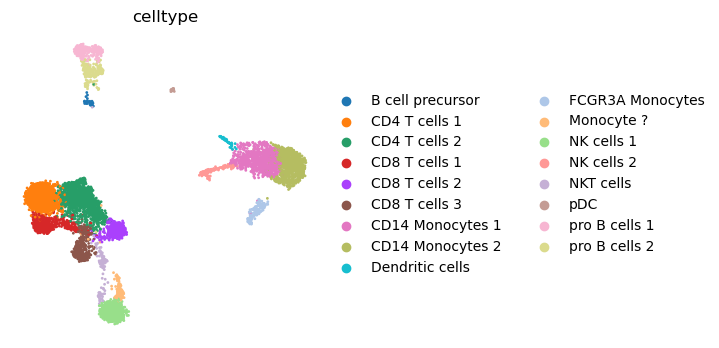

In [12]:
# Plot the umap colored by cell types
sc.pl.umap(ad, color="celltype", frameon=False)

The above function uses the `ad.obms['X_umap']` to plot the umap. If you want to use an alternative visualization, you can use the `sc.pl.scatter` function and specify the representation with the `basis` argument.

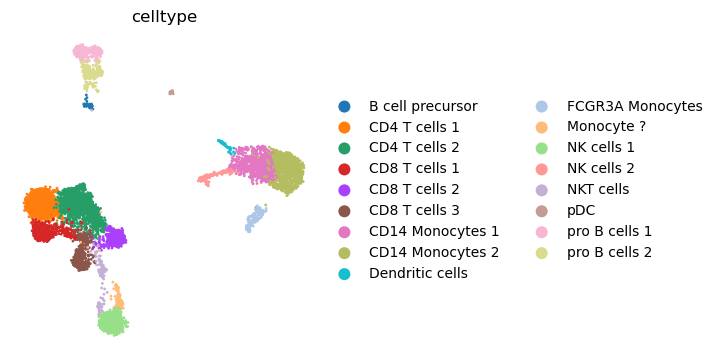

In [13]:
# Plot the umap colored by cell types
sc.pl.scatter(ad, color="celltype", basis="umap", frameon=False)

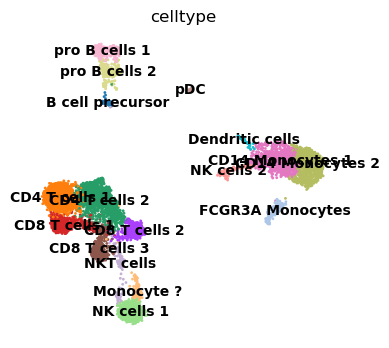

In [16]:
# We can highlight cell-types on the umap itself
sc.pl.umap(ad, color="celltype", legend_loc="on data", frameon=False)

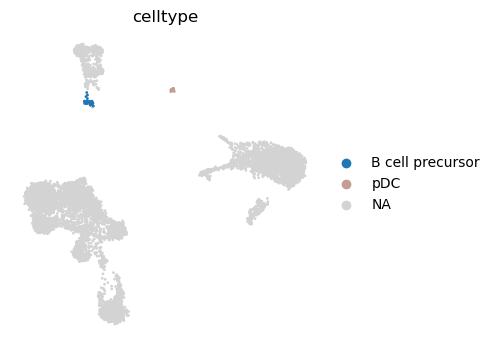

In [17]:
# Or plot specific cell types
sc.pl.umap(ad, color="celltype", groups=["pDC", "B cell precursor"], frameon=False)

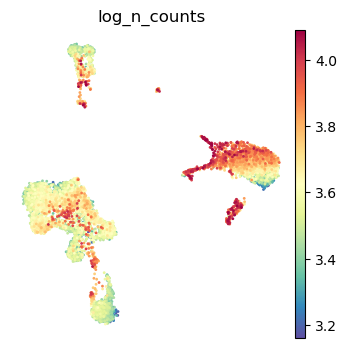

In [18]:
# UMAPs can be colored by continuous values too
sc.pl.umap(ad, color="log_n_counts", frameon=False)

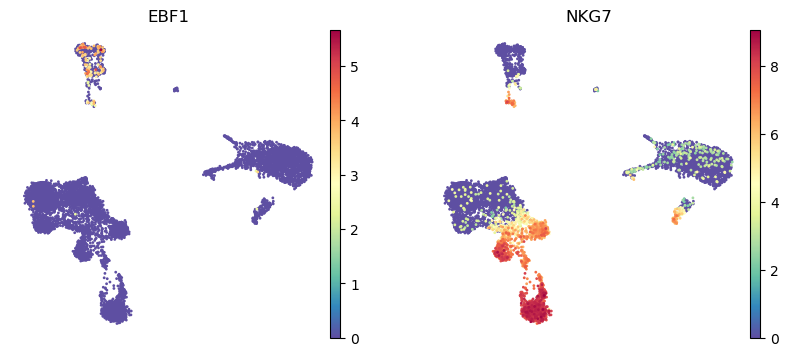

In [19]:
# Or by gene expression values
sc.pl.umap(ad, color=["EBF1", "NKG7"], frameon=False)

# Part4: Additional resoruces

**Preprocessing**: link to process notebook   
**Cell Type Annotation** : link to cell type annotation